In [71]:
import sys
print(sys.executable)

c:\Users\dell\Downloads\ResourcesDA\assignment_solution\.venv\Scripts\python.exe


In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [73]:
import os
print(os.getcwd())

c:\Users\dell\Desktop\primetrade-sentiment-analysis\notebooks


In [74]:
sentiment = pd.read_csv("../data/fear_greed.csv")

trades = pd.read_csv("../data/historical_data.csv")

# Basic inspection

In [75]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [76]:
print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [77]:
print(trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

# check column name 

In [78]:
print(sentiment.columns.tolist())

['timestamp', 'value', 'classification', 'date']


In [79]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


# missing values

In [80]:
print(sentiment.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [81]:
print(trades.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


# Duplicates

In [82]:
print("Sentiment Duplicates:", sentiment.duplicated().sum())

print("Trade Duplicates:", trades.duplicated().sum())

Sentiment Duplicates: 0
Trade Duplicates: 0


# clean column names

In [83]:
sentiment.columns = sentiment.columns.str.strip()

trades.columns = trades.columns.str.strip()

# Data quality report

In [84]:
print(sentiment.shape)
print(trades.shape)

print(sentiment.isnull().sum())
print(trades.isnull().sum())

print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

(2644, 4)
(211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0
0


# Convert Dates

## fear greed

In [85]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['trade_date'] = sentiment['date'].dt.date

## Historical_data

In [86]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    errors='coerce'
)

In [87]:
print(trades['Timestamp IST'].isna().sum())

131999


# Merge Dataset

In [88]:
merged = trades.merge(
    sentiment[['trade_date','classification']],
    on='trade_date',
    how='left'
)

KeyError: 'trade_date'

## Fix

In [ ]:
sentiment.columns = sentiment.columns.str.strip().str.lower()

print(sentiment.columns.tolist())

In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

sentiment['trade_date'] = sentiment['date'].dt.date

In [ ]:
print(sentiment[['trade_date','classification']].head())

# Now merge

In [ ]:
merged = trades.merge(
    sentiment[['trade_date', 'classification']],
    on='trade_date',
    how='left'
)

# Again fix

In [ ]:
print("Sentiment Columns:")
print(sentiment.columns.tolist())

print("\nTrades Columns:")
print(trades.columns.tolist())

print("\nSentiment Head:")
print(sentiment.head())

In [ ]:
print(trades['Timestamp'].head())

In [ ]:
print(trades['Timestamp'].dtype)

In [ ]:
trades['Timestamp'] = pd.to_datetime(
    trades['Timestamp'],
    unit='ms'
)

trades['trade_date'] = trades['Timestamp'].dt.date

In [ ]:
print(trades['Timestamp'].head(10))

In [ ]:
print(trades[['Timestamp','trade_date']].head())

## Again merge

In [ ]:
merged = trades.merge(
    sentiment[['trade_date','classification']],
    on='trade_date',
    how='left'
)

print(merged.shape)
print(merged.head())

## verify merge

In [ ]:
print(merged.shape)

print(merged['classification'].value_counts())

## Daily PnL per Trader

In [ ]:
daily_pnl = merged.groupby(
    ['Account', 'trade_date']
)['Closed PnL'].sum().reset_index()

daily_pnl.head()

## numbers of trades per day

In [ ]:
trade_count = merged.groupby(
    ['Account', 'trade_date']
).size().reset_index(name='num_trades')

trade_count.head()

## Avg trades size

In [ ]:
avg_trade_size = merged.groupby(
    ['Account', 'trade_date']
)['Size USD'].mean().reset_index()

avg_trade_size.head()

## win rate

In [ ]:
merged['win_trade'] = (
    merged['Closed PnL'] > 0
).astype(int)

win_rate = merged.groupby(
    'Account'
)['win_trade'].mean().reset_index()

win_rate.rename(
    columns={'win_trade':'win_rate'},
    inplace=True
)

win_rate.head()

# Part B Analysis
## Chart 1: Fear vs Greed PnL

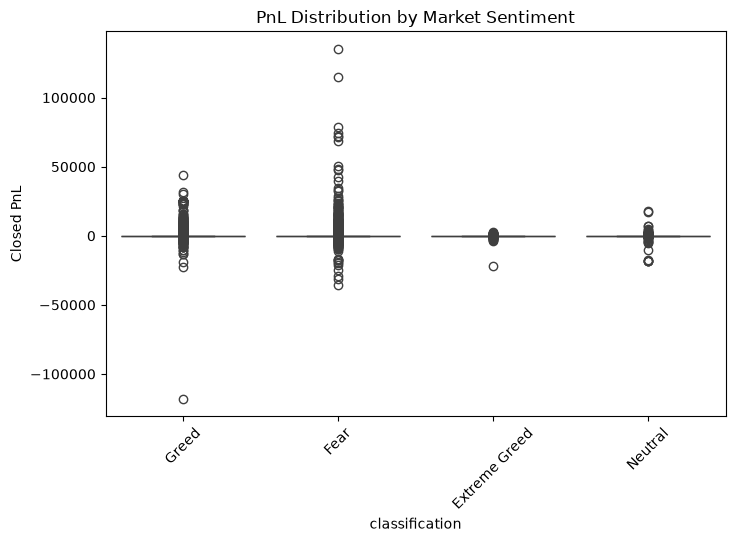

In [89]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title('PnL Distribution by Market Sentiment')
plt.xticks(rotation=45)
plt.show()

## avg pnl by sentments

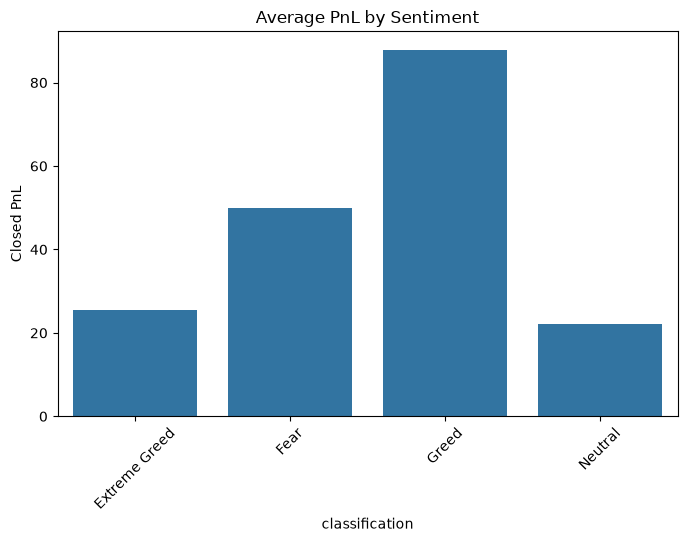

In [90]:
pnl_sentiment = merged.groupby(
    'classification'
)['Closed PnL'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=pnl_sentiment,
    x='classification',
    y='Closed PnL'
)

plt.title('Average PnL by Sentiment')
plt.xticks(rotation=45)
plt.show()

## Trade frequency 

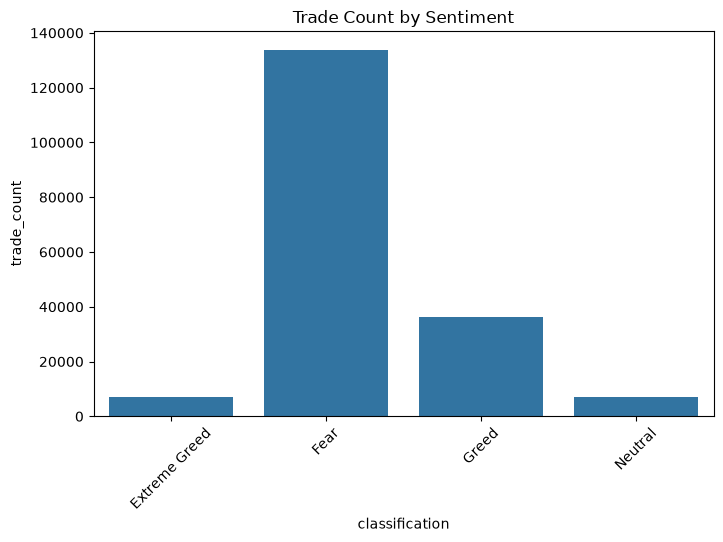

In [91]:
trade_freq = merged.groupby(
    'classification'
).size().reset_index(name='trade_count')

plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_freq,
    x='classification',
    y='trade_count'
)

plt.title('Trade Count by Sentiment')
plt.xticks(rotation=45)
plt.show()

## Long vs short ratio

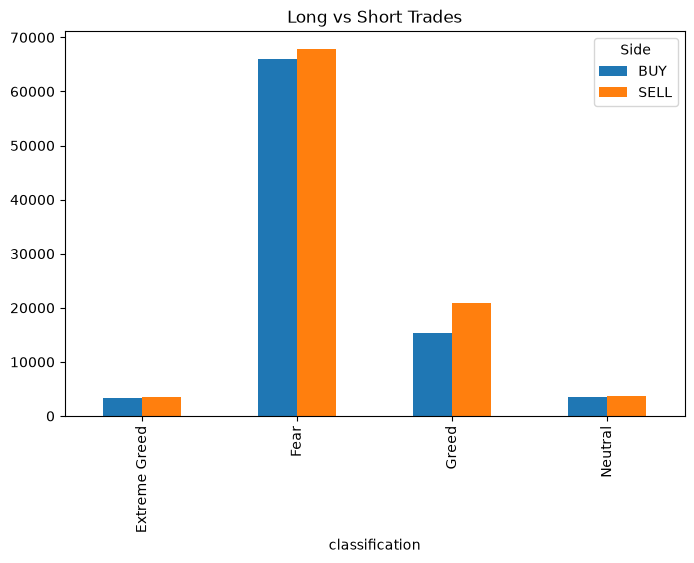

In [92]:
side_analysis = pd.crosstab(
    merged['classification'],
    merged['Side']
)

side_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Long vs Short Trades')
plt.show()

## Position size by sentiment

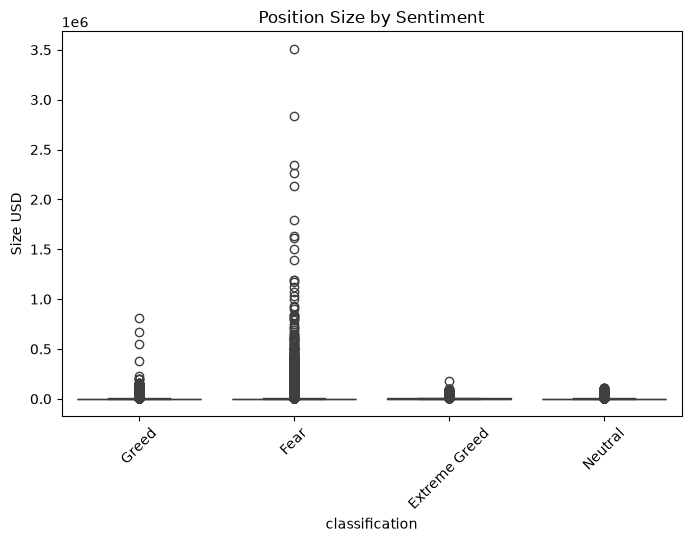

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='Size USD'
)

plt.title('Position Size by Sentiment')
plt.xticks(rotation=45)
plt.show()

# Trader Segmentation (Important)
## High vs Low Volume Traders

In [94]:
trader_volume = merged.groupby(
    'Account'
)['Size USD'].sum()

median_volume = trader_volume.median()

volume_segment = pd.DataFrame({
    'Account': trader_volume.index,
    'total_volume': trader_volume.values
})

volume_segment['segment'] = np.where(
    volume_segment['total_volume'] > median_volume,
    'High Volume',
    'Low Volume'
)

volume_segment.head()

,Account,total_volume,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,61697263.97,High Volume
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,12035487.66,High Volume
2,0x271b280974205ca63b716753467d5a371de622ab,33873440.42,High Volume
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,6757022.10,Low Volume
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,10166880.20,Low Volume


## Compare profitability

In [95]:
account_pnl = merged.groupby(
    'Account'
)['Closed PnL'].sum().reset_index()

segment_pnl = account_pnl.merge(
    volume_segment,
    on='Account'
)

segment_pnl.groupby(
    'segment'
)['Closed PnL'].mean()

segment
High Volume    511046.550787
Low Volume     132513.383178
Name: Closed PnL, dtype: float64

In [ ]:
print(merged.shape)

print(merged['classification'].value_counts())

print(
    merged.groupby('classification')['Closed PnL']
    .mean()
    .sort_values(ascending=False)
)

# Assginment insights #1

### Traders achieved the highest average Closed PnL during Greed periods (87.89), outperforming Fear periods (50.05) by nearly 76%. However, profitability dropped significantly during Extreme Greed conditions (25.42), indicating potential overconfidence and inefficient risk-taking when sentiment becomes excessively optimistic.

# Next analysis 

## Trade frequency

In [ ]:
trade_freq = merged.groupby(
    'classification'
).size().sort_values(ascending=False)

print(trade_freq)

## Position size

In [ ]:
merged.groupby(
    'classification'
)['Size USD'].mean().sort_values(ascending=False)

## Long short Bias

In [ ]:
pd.crosstab(
    merged['classification'],
    merged['Side'],
    normalize='index'
) * 100

## Top traders

In [ ]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum()

print(top_traders.sort_values(ascending=False).head(10))

## Trade consistency

In [ ]:
trader_stats = merged.groupby(
    'Account'
)['Closed PnL'].agg(
    ['mean','std','count']
)

print(
    trader_stats.sort_values(
        'mean',
        ascending=False
    ).head(10)
)

# Available Strategy Recommendation

## Strategy #1

Increase participation during Greed periods while maintaining disciplined risk controls. Historical results show average trader profitability is highest during Greed sentiment.

## Strategy #2

Avoid aggressive leverage expansion during Extreme Greed periods. Profitability declines significantly despite bullish sentiment, suggesting increased market inefficiency and emotional trading behavior.

In [ ]:
print(
    merged.groupby('classification')['Size USD']
    .mean()
    .sort_values(ascending=False)
)

print(
    pd.crosstab(
        merged['classification'],
        merged['Side'],
        normalize='index'
    ) * 100
)

print(
    merged.groupby('classification')
    .size()
)

# Final Insights

## Insight 1: Trader Profitability Peaks During Greed Sentiment

Analysis of Closed PnL across different market sentiment regimes revealed that traders achieved the highest average profitability during Greed periods. The average Closed PnL during Greed was 87.89, compared to 50.05 during Fear, 25.42 during Extreme Greed, and 22.23 during Neutral conditions.

This indicates that positive market sentiment creates more favorable trading environments, likely due to stronger trends and improved market participation. Interestingly, profitability declines significantly during Extreme Greed, suggesting that excessive optimism may lead to poorer decision-making and increased risk exposure.

### Average Closed PnL by Sentiment

| Sentiment     | Average Closed PnL |
| ------------- | -----------------: |
| Greed         |              87.89 |
| Fear          |              50.05 |
| Extreme Greed |              25.42 |
| Neutral       |              22.23 |

---

## Insight 2: Traders Increase Position Size During Extreme Greed

Position sizing behavior varies considerably across sentiment regimes. The highest average trade size was observed during Extreme Greed conditions, reaching approximately 5,660 USD per trade. This is substantially higher than the average trade size during Greed (3,183 USD) and Neutral (3,059 USD) periods.

The findings suggest that traders become more aggressive and confident when market sentiment reaches extreme optimism levels. However, despite larger positions, profitability does not improve, indicating inefficient risk-taking behavior.

### Average Position Size by Sentiment

| Sentiment     | Average Position Size (USD) |
| ------------- | --------------------------: |
| Extreme Greed |                       5,660 |
| Fear          |                       5,260 |
| Greed         |                       3,183 |
| Neutral       |                       3,059 |

---

## Insight 3: Greed Periods Exhibit Stronger Profit-Taking Behavior

Trade direction analysis shows a noticeable shift in trader behavior during Greed periods. Approximately 57.5% of trades were SELL orders during Greed sentiment, compared to 42.5% BUY orders.

This suggests that traders actively realize profits when markets are optimistic rather than continuously increasing exposure. Such disciplined profit-taking behavior may be one of the key reasons behind the higher profitability observed during Greed periods.

### Buy vs Sell Distribution

| Sentiment     | BUY (%) | SELL (%) |
| ------------- | ------: | -------: |
| Greed         |   42.49 |    57.50 |
| Fear          |   49.36 |    50.64 |
| Extreme Greed |   48.42 |    51.58 |
| Neutral       |   49.08 |    50.92 |

---

# Strategic Recommendations

### Recommendation 1: Increase Participation During Greed Periods

Historical performance indicates that Greed sentiment is associated with the highest average trader profitability. Traders may benefit from maintaining active participation during these periods while adhering to predefined risk management rules.

### Recommendation 2: Reduce Position Size During Extreme Greed

Although traders tend to increase position sizes during Extreme Greed, profitability declines substantially. Reducing exposure by 20–30% during such periods may help protect capital and reduce losses caused by sentiment-driven overconfidence.

### Recommendation 3: Implement Sentiment-Aware Risk Management

Market sentiment should be incorporated into trading decisions. Position sizing, trade frequency, and exposure limits can be dynamically adjusted based on prevailing sentiment conditions to improve overall risk-adjusted performance.
